# QuantConnect Deployment: Prediction Export Bridge

**Docker image**: `ml4t`

**Section Reference**: 25.4 (QuantConnect and Managed Platforms)

This notebook demonstrates deploying the book's ML pipeline to QuantConnect
using a **precomputed-predictions** pattern. Instead of reimplementing feature
engineering inside LEAN, we export frozen predictions from the ETFs case study
and let a lightweight LEAN algorithm consume them for portfolio construction.

**Structure**:
1. Load predictions from the ETFs case study pipeline
2. Export as QuantConnect-compatible JSON (Object Store format)
3. Show the LEAN algorithm that reads predictions and rebalances
4. Link to an illustrative QuantConnect Cloud project
5. Compare precomputed vs inline-inference deployment workflows

**Learning Objectives**
- Export ML predictions from the book's pipeline into a format consumable by
  an external backtesting platform.
- Read a working LEAN algorithm that separates portfolio rules from ML inference.
- Evaluate when precomputed predictions are preferable to inline model inference.

**Prerequisites**
- ETFs case study pipeline (Chapters 7-12), which produces the predictions we export
- Section 25.4 on managed platforms and build-vs-buy decisions
- `unified_framework_demo` for the self-hosted alternative

## 1. Load Predictions from the ETFs Pipeline

The ETFs case study pipeline trains models in Chapters 11–15 and stores
predictions in the registry. We load them here for export.

In [1]:
"""Export ML predictions for consumption by LEAN algorithms."""

import warnings

warnings.filterwarnings("ignore")

import hashlib
import json
import sqlite3

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import polars as pl
from demo_artifacts import normalize_demo_predictions

from utils.paths import display_path, get_case_study_dir, get_output_dir
from utils.style import COLORS, FIGSIZE, add_message_title

In [2]:
HORIZON = 21
PREDICTION_THRESHOLD = 0.0
# What this export depends on: the configuration the registry selects, and the
# bytes of that configuration's sealed holdout predictions. The registry file
# itself is not pinned. It accumulates rows from every run in the case study,
# so its hash moves whether or not the selection moves, which would make a
# whole-file pin fail on runs that export exactly the right predictions. Set a
# pin to None to report the observed value instead of asserting it.
EXPECTED_TRAINING_HASH = "0488120b490e"
EXPECTED_PREDICTIONS_SHA256 = "b3b12dcdfac8a0c59b80609b6c81aff203828a3e19a2d992b1da993185a34b48"
EXPORT_PATH = get_output_dir(25, "quantconnect_export") / "ml4t_qc_predictions.json"

In [3]:
case_study_dir = get_case_study_dir("etfs")
registry_path = case_study_dir / "run_log" / "registry.db"
registry_hash_before = hashlib.sha256(registry_path.read_bytes()).hexdigest()

# Resolve the selected cross-stage winner and its one sealed holdout prediction
# set using a read-only immutable SQLite connection. This cannot create a WAL,
# journal, or transaction side effect in the canonical case-study registry.
registry_uri = f"{registry_path.resolve().as_uri()}?mode=ro&immutable=1"
with sqlite3.connect(registry_uri, uri=True) as conn:
    winner = conn.execute(
        """SELECT ps.training_hash, br.backtest_hash, br.stage, bm.sharpe
           FROM backtest_runs br
           JOIN backtest_metrics bm ON br.backtest_hash = bm.backtest_hash
           JOIN prediction_sets ps ON br.prediction_hash = ps.prediction_hash
           WHERE br.stage IN ('signal', 'allocation', 'risk_overlay')
           ORDER BY bm.sharpe DESC LIMIT 1"""
    ).fetchone()
    if winner is None:
        raise RuntimeError("ETF registry has no eligible cross-stage backtest winner")
    holdout_rows = conn.execute(
        """SELECT prediction_hash FROM prediction_sets
           WHERE training_hash = ? AND split = 'holdout'
           ORDER BY prediction_hash""",
        (winner[0],),
    ).fetchall()

assert EXPECTED_TRAINING_HASH in (None, winner[0]), (
    f"The registry now selects a different configuration: {winner[0]}"
)
assert len(holdout_rows) == 1, f"Expected one sealed holdout set, found {len(holdout_rows)}"
prediction_hash = holdout_rows[0][0]
prediction_path = (
    case_study_dir / "run_log" / "predictions" / prediction_hash / "predictions.parquet"
)
prediction_file_hash = hashlib.sha256(prediction_path.read_bytes()).hexdigest()
assert EXPECTED_PREDICTIONS_SHA256 in (None, prediction_file_hash), (
    f"Holdout prediction set provenance changed: {prediction_file_hash}"
)
predictions = normalize_demo_predictions(pl.read_parquet(prediction_path), "symbol")
registry_hash_after_load = hashlib.sha256(registry_path.read_bytes()).hexdigest()
assert registry_hash_after_load == registry_hash_before

print(f"Registry SHA256: {registry_hash_before}")
print(f"Prediction parquet SHA256: {prediction_file_hash}")
print(f"Training hash: {winner[0]} | holdout prediction hash: {prediction_hash}")
print(f"Selection stage: {winner[2]} | backtest hash: {winner[1]}")

n_dates = predictions["timestamp"].n_unique()
n_symbols = predictions["symbol"].n_unique()

print(f"Loaded {len(predictions):,} predictions")
print(
    f"  Dates: {n_dates:,} ({predictions['timestamp'].min()} to {predictions['timestamp'].max()})"
)
print(f"  Symbols: {n_symbols}")

predictions.head(10)

Registry SHA256: 0016814bcf1d0194f14548c5a0018092a607ad2a55ce42a18c08e9b6319dd9e3
Prediction parquet SHA256: b3b12dcdfac8a0c59b80609b6c81aff203828a3e19a2d992b1da993185a34b48
Training hash: 0488120b490e | holdout prediction hash: 3bc3fbdcc43d
Selection stage: risk_overlay | backtest hash: af67c54473fb
Loaded 44,733 predictions
  Dates: 481 (2024-01-02 to 2025-12-01)
  Symbols: 95


timestamp,symbol,prediction
date,str,f64
2024-01-02,"""ACWI""",0.032551
2024-01-03,"""ACWI""",0.030244
2024-01-04,"""ACWI""",0.020609
2024-01-05,"""ACWI""",0.008919
2024-01-08,"""ACWI""",-0.002047
2024-01-09,"""ACWI""",-0.008843
2024-01-10,"""ACWI""",-0.014256
2024-01-11,"""ACWI""",-0.016171
2024-01-12,"""ACWI""",-0.019002


**Finding**: The predictions span the sealed holdout period, the
out-of-sample window the model never saw during selection, with daily
coverage across the surviving ETF universe (typically 90+ symbols per day
after liquidity filters). Exporting the holdout, not the validation split, is
deliberate: a deployment backtest must run on data untouched by model
selection. Each row is a single model's out-of-sample score for one symbol on
one date.

**Trading implication**: Exporting frozen predictions decouples portfolio-rule
iteration from the ML pipeline. You can test different thresholds, position
limits, and rebalance frequencies without retraining.

## 2. Export as QuantConnect-Compatible JSON

QuantConnect's Object Store accepts JSON. We format predictions to match the
pattern used in the
[illustrative QuantConnect project](https://www.quantconnect.cloud/backtest/37075c225715df9ef4477dc748b1cbf7/?theme=darkly)
(account access may be required):
one entry per date, each containing a symbol-to-prediction mapping.

In [4]:
# Group by date and create QC-compatible JSON
date_groups = (
    predictions.sort("timestamp")
    .group_by("timestamp")
    .agg(
        [
            pl.col("symbol").alias("symbols"),
            pl.col("prediction").alias("predictions"),
        ]
    )
    .sort("timestamp")
)

qc_predictions = []
for row in date_groups.iter_rows(named=True):
    date_str = str(row["timestamp"])
    prediction_by_symbol = dict(zip(row["symbols"], row["predictions"], strict=False))
    qc_predictions.append(
        {
            "date": date_str,
            "prediction_by_symbol": prediction_by_symbol,
        }
    )

print(f"Formatted {len(qc_predictions)} daily prediction entries")
print(
    f"First date: {qc_predictions[0]['date']}, symbols: {len(qc_predictions[0]['prediction_by_symbol'])}"
)
print(
    f"Last date:  {qc_predictions[-1]['date']}, symbols: {len(qc_predictions[-1]['prediction_by_symbol'])}"
)

Formatted 481 daily prediction entries
First date: 2024-01-02, symbols: 93
Last date:  2025-12-01, symbols: 93


In [5]:
# Show sample entry
sample = qc_predictions[-1]
sample_symbols = dict(list(sample["prediction_by_symbol"].items())[:5])
print(f"\nSample entry ({sample['date']}):")
for symbol, pred in sample_symbols.items():
    direction = "long" if pred > 0 else "short" if pred < 0 else "neutral"
    print(f"  {symbol}: {pred:+.4f} ({direction})")


Sample entry (2025-12-01):
  ACWI: +0.0093 (long)
  ACWX: +0.0047 (long)
  AGG: +0.0003 (long)
  BIL: -0.0296 (short)
  BND: +0.0037 (long)


**Finding**: Each date entry maps symbols to predictions. Positive predictions
become long candidates; the threshold determines which make it into the portfolio.

In [6]:
# Write to disk
json_str = json.dumps(qc_predictions, indent=2)
EXPORT_PATH.write_text(json_str)

file_size_kb = EXPORT_PATH.stat().st_size / 1024
print(f"Exported to {display_path(EXPORT_PATH)}")
print(f"  File size: {file_size_kb:.0f} KB")
print(f"  Entries: {len(qc_predictions)} dates")

Exported to 25_live_trading/output/quantconnect_export/ml4t_qc_predictions.json
  File size: 1587 KB
  Entries: 481 dates


**Finding**: The full prediction history exports to a compact JSON file. On
QuantConnect, this would be uploaded to the Object Store via
`qb.object_store.save('research-to-backtest-factors.json', json_str)` in a
Research Notebook, using the same filename the LEAN algorithm reads in Section 3.

**Trading implication**: Small file sizes mean fast iteration. Changing the
threshold or adding a risk filter does not require re-uploading predictions.

## 3. The LEAN Algorithm

The algorithm file is deliberately tiny. All feature engineering and model
inference happened in the research step (our pipeline). The algorithm just
reads predictions and rebalances.

This is the actual pattern from the
[illustrative QuantConnect project](https://www.quantconnect.cloud/backtest/37075c225715df9ef4477dc748b1cbf7/?theme=darkly).

### Custom Universe: Reading Predictions from Object Store

The `PredictionUniverse` class defines a custom data source that reads the
JSON we exported. LEAN streams it date-by-date into the algorithm.

```python
class PredictionUniverse(PythonData):
    def get_source(self, config, date, is_live_mode):
        return SubscriptionDataSource(
            'research-to-backtest-factors.json',
            SubscriptionTransportMedium.OBJECT_STORE,
            FileFormat.UNFOLDING_COLLECTION
        )

    def reader(self, config, line, date, is_live):
        objects = []
        for obj in json.loads(line):
            end_time = datetime.strptime(obj["date"], "%Y-%m-%d")
            for ticker, prediction in obj['prediction_by_symbol'].items():
                stock = PredictionUniverse()
                stock.symbol = Symbol.create(
                    ticker, SecurityType.EQUITY, Market.USA
                )
                stock.end_time = end_time
                stock.value = prediction
                objects.append(stock)
        return BaseDataCollection(
            objects[-1].end_time, config.symbol, objects
        )
```

The `UNFOLDING_COLLECTION` format tells LEAN to stream one date at a time,
so the algorithm only sees data available on each historical day.

### Algorithm: Select and Rebalance

The algorithm subscribes to assets with positive predictions and forms an
equal-weighted portfolio. The exported signal is a 21-day forward return, so
the rebalance fires monthly, matching the holding period the signal was
trained for and the ETF strategy's own monthly cadence (Chapters 16-17).

```python
class PredictionUniverseAlgorithm(QCAlgorithm):
    def initialize(self):
        self.set_start_date(2020, 1, 1)
        self.set_cash(100_000)
        self.settings.seed_initial_prices = True
        self._return_prediction_threshold = 0

        self.universe_settings.resolution = Resolution.DAILY
        self._universe = self.add_universe(
            PredictionUniverse, self._select_assets
        )

        # Rebalance monthly to match the 21-day prediction horizon. The
        # universe still streams daily; only the rebalance is throttled.
        self.schedule.on(
            self.date_rules.month_start('SPY'),
            self.time_rules.at(8, 0),
            self._rebalance,
        )

    def _select_assets(self, data):
        return [
            stock.symbol for stock in data
            if stock.value > self._return_prediction_threshold
        ]

    def _rebalance(self):
        symbols = self._universe.selected
        if not symbols:
            return
        targets = [
            PortfolioTarget(symbol, 1 / len(symbols))
            for symbol in symbols
        ]
        self.set_holdings(targets, True)
```

The entire algorithm is ~30 lines. Portfolio rules (threshold, weighting,
rebalance frequency) can be changed without touching the ML pipeline. Matching
the rebalance to the signal's 21-day horizon is itself an instance of that
freedom: aligning cadence with the prediction is a one-line change here, not a
retraining run.

## 4. Running on QuantConnect

### Cloud Path (No Local Setup)

An illustrative project shows the precomputed-predictions pattern:

**[View Backtest Results](https://www.quantconnect.cloud/backtest/37075c225715df9ef4477dc748b1cbf7/?theme=darkly)**

To use it:
1. Create a free QuantConnect account
2. Open or clone the project if your account has access
3. Upload your prediction JSON to the Object Store as
   `research-to-backtest-factors.json` (the name the algorithm reads)
4. Run the backtest

The Research Notebook in the project shows how to train a model on
QuantConnect's own S&P 500 data and export predictions. Our export step
above produces the same JSON format, so you can substitute your own
predictions.

### Local Docker Path (Optional)

QuantConnect documents the supported local workflow in the
[LEAN CLI guide](https://www.quantconnect.com/docs/v2/lean-cli). The CLI uses
Docker to initialize a project, run LEAN, and collect backtest results. Follow
that guide for current installation and authentication commands; the export
produced above remains the Object Store input.

## 5. Prediction Signal Analysis

Before deploying, verify the prediction distribution is sensible.

In [7]:
# Analyze the predictions we exported
positive = predictions.filter(pl.col("prediction") > PREDICTION_THRESHOLD)
negative = predictions.filter(pl.col("prediction") <= PREDICTION_THRESHOLD)

print("Prediction Distribution:")
print(f"  Total:    {len(predictions):,}")
print(f"  Long:     {len(positive):,} ({100 * len(positive) / len(predictions):.1f}%)")
print(f"  Excluded: {len(negative):,} ({100 * len(negative) / len(predictions):.1f}%)")
print(f"  Mean:     {predictions['prediction'].mean():.4f}")
print(f"  Std:      {predictions['prediction'].std():.4f}")

# Average portfolio size per date
portfolio_sizes = (
    predictions.filter(pl.col("prediction") > PREDICTION_THRESHOLD)
    .group_by("timestamp")
    .agg(pl.col("symbol").count().alias("n_holdings"))
)

print(f"\nPortfolio Size (equal-weight, threshold={PREDICTION_THRESHOLD}):")
print(f"  Mean:   {portfolio_sizes['n_holdings'].mean():.1f} holdings/day")
print(f"  Min:    {portfolio_sizes['n_holdings'].min()}")
print(f"  Max:    {portfolio_sizes['n_holdings'].max()}")

Prediction Distribution:
  Total:    44,733
  Long:     18,728 (41.9%)
  Excluded: 26,005 (58.1%)
  Mean:     -0.0074
  Std:      0.0266

Portfolio Size (equal-weight, threshold=0.0):
  Mean:   38.9 holdings/day
  Min:    3
  Max:    85


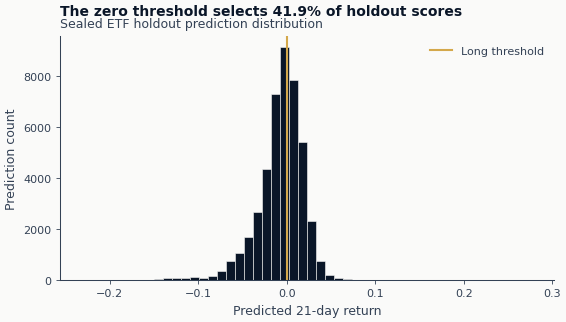

In [8]:
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.hist(
    predictions["prediction"].to_numpy(),
    bins=50,
    color=COLORS["blue"],
    edgecolor=COLORS["silver"],
    linewidth=0.4,
)
ax.axvline(PREDICTION_THRESHOLD, color=COLORS["amber"], linewidth=1.5, label="Long threshold")
ax.set(xlabel="Predicted 21-day return", ylabel="Prediction count")
ax.legend(frameon=False)
add_message_title(
    ax,
    f"The zero threshold selects {100 * len(positive) / len(predictions):.1f}% of holdout scores",
    subtitle="Sealed ETF holdout prediction distribution",
)
fig.tight_layout()
plt.show()

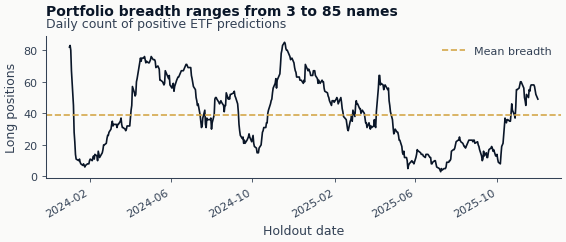

In [9]:
portfolio_sizes = portfolio_sizes.sort("timestamp")
fig, ax = plt.subplots(figsize=FIGSIZE["single_wide"])
ax.plot(
    portfolio_sizes["timestamp"].to_list(),
    portfolio_sizes["n_holdings"].to_list(),
    color=COLORS["blue"],
    linewidth=1.2,
)
ax.axhline(
    portfolio_sizes["n_holdings"].mean(),
    color=COLORS["amber"],
    linewidth=1.2,
    linestyle="--",
    label="Mean breadth",
)
ax.set(xlabel="Holdout date", ylabel="Long positions")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.tick_params(axis="x", labelrotation=30)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")
ax.legend(frameon=False)
add_message_title(
    ax,
    (
        f"Portfolio breadth ranges from {portfolio_sizes['n_holdings'].min()} "
        f"to {portfolio_sizes['n_holdings'].max()} names"
    ),
    subtitle="Daily count of positive ETF predictions",
)
fig.tight_layout()
plt.show()

**Finding**: The prediction distribution determines portfolio breadth. The
output above computes the positive-score share and daily holding counts rather
than relying on a frozen headline number. Higher thresholds concentrate the
portfolio into fewer names.

**Trading implication**: Threshold tuning is now a portfolio-construction
decision, not a modeling decision. That is the intended separation.

## 6. Two Deployment Workflows Compared

The precomputed-predictions pattern is one of two ways to deploy ML strategies.
The choice depends on how often predictions change and how fast you need to
iterate on portfolio rules.

| Aspect | Precomputed Predictions | Inline Inference |
|--------|----------------------|------------------|
| **Pipeline** | Train offline, export JSON, then read predictions | Train offline, serialize model, then call `predict()` |
| **Iteration speed** | Threshold/weight changes reuse frozen scores | Threshold/weight changes stay local; model changes rerun inference |
| **Prediction freshness** | Frozen at export time | Always current |
| **Reproducibility** | Stable input: same JSON under versioned engine rules | Depends on model and runtime versions |
| **Best for** | Portfolio rule experimentation, walk-forward analysis | Live trading with streaming data |
| **Book pipeline** | Chapters 7-15, export, then Ch25 QC notebook | Model serialized and loaded in `Initialize()` |

Both workflows are valid. The book's pipeline naturally produces precomputed
predictions (one run per model, label, and fold), making the export pattern
the lower-friction path for backtesting. For live trading, QuantConnect's
[ML documentation](https://www.quantconnect.com/docs/v2/writing-algorithms/machine-learning/key-concepts)
documents the inline-inference approach with serialized models.

## Summary

This notebook demonstrated the prediction export bridge between the book's
ML pipeline and QuantConnect's LEAN engine:

1. **Loaded** the output-counted ETF holdout predictions from the exact registry hash printed above
2. **Exported** as QC-compatible JSON (Object Store format)
3. **Showed** the ~30-line LEAN algorithm that consumes predictions
4. **Linked** to an illustrative project on QuantConnect Cloud
5. **Compared** precomputed vs inline deployment workflows

## Key Takeaways

1. **Separation of concerns**: The ML pipeline (Chapters 7–15) produces
   predictions; the deployment platform (QuantConnect or self-hosted) handles
   portfolio construction and execution. Changing one does not require
   changing the other.
2. **Precomputed predictions enable fast iteration**: Testing different
   thresholds, position limits, or rebalance rules takes seconds because
   the expensive model training is already done.
3. **Platform choice is an infrastructure decision**: QuantConnect provides
   data, execution, and hosting; the self-hosted path (`unified_framework_demo`,
   `ml4t-backtest`) provides flexibility. The prediction format is portable
   between both.

**Next**: See `unified_framework_demo` and `etfs_deployment_loop` for the
self-hosted path, or `pipeline_verification` for systematic parity testing.

In [10]:
registry_hash_final = hashlib.sha256(registry_path.read_bytes()).hexdigest()
assert registry_hash_final == registry_hash_before
print(f"Registry unchanged after export and analysis: {registry_hash_final}")

Registry unchanged after export and analysis: 0016814bcf1d0194f14548c5a0018092a607ad2a55ce42a18c08e9b6319dd9e3
